In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42


In [2]:
df = pd.read_csv(r"C:\Users\Hp\Downloads\student+performance\student\student-por.csv", sep=";")
print("Shape:", df.shape)
df.head()


Shape: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [4]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())


Missing values: 0
Duplicate rows: 0


In [5]:
df.describe()


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [6]:
ABSENCE_THRESHOLD = 6

df["attendance_status"] = np.where(
    df["absences"] > ABSENCE_THRESHOLD, "Low Attendance", "Satisfactory"
)

df["attendance_status"].value_counts()


attendance_status
Satisfactory      527
Low Attendance    122
Name: count, dtype: int64

C:\Users\Hp\AppData\Local\Temp\ipykernel_7020\1108452718.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="attendance_status",


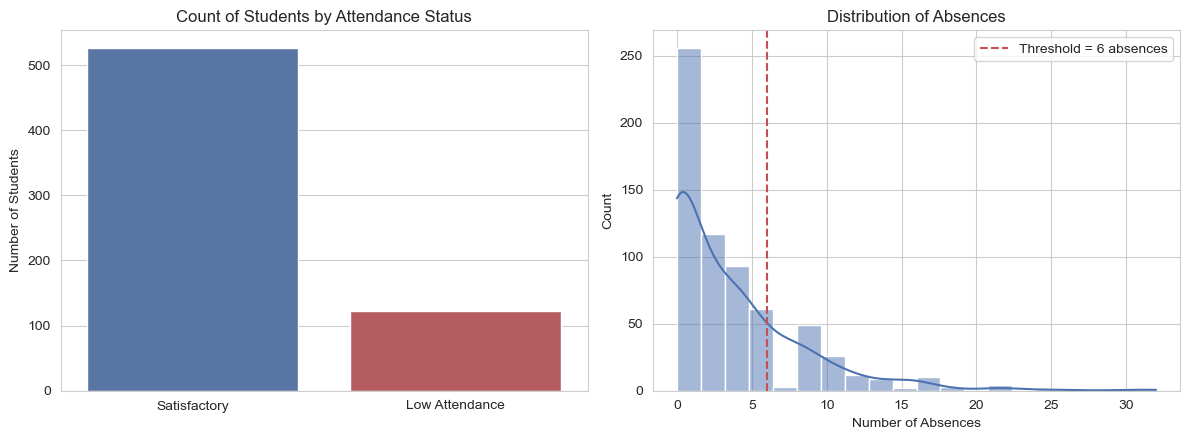

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(data=df, x="attendance_status",
              order=["Satisfactory", "Low Attendance"],
              palette=["#4C72B0", "#C44E52"], ax=axes[0])
axes[0].set_title("Count of Students by Attendance Status")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Students")

sns.histplot(df["absences"], bins=20, kde=True, color="#4C72B0", ax=axes[1])
axes[1].axvline(ABSENCE_THRESHOLD, color="#C44E52", linestyle="--",
                label=f"Threshold = {ABSENCE_THRESHOLD} absences")
axes[1].set_title("Distribution of Absences")
axes[1].set_xlabel("Number of Absences")
axes[1].legend()

plt.tight_layout()
plt.show()


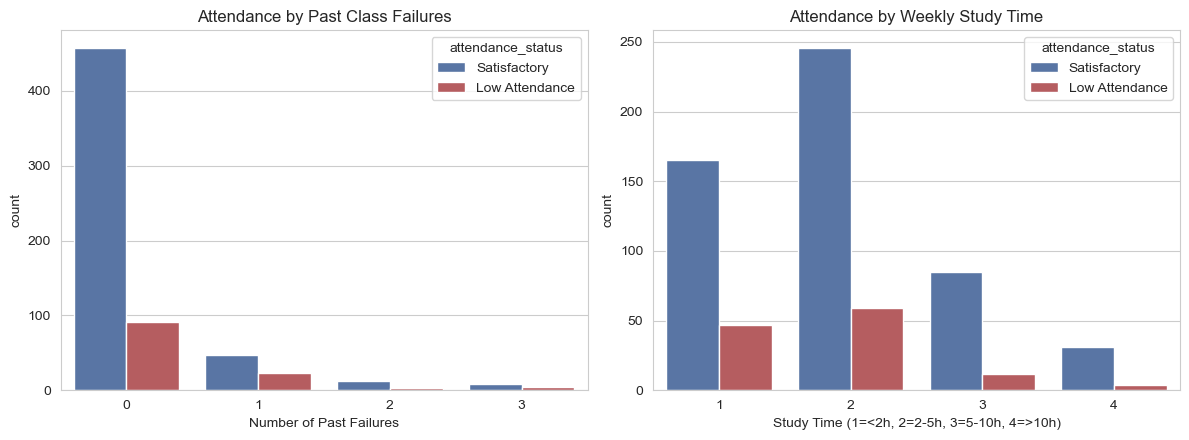

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(data=df, x="failures", hue="attendance_status",
              palette=["#4C72B0", "#C44E52"], ax=axes[0])
axes[0].set_title("Attendance by Past Class Failures")
axes[0].set_xlabel("Number of Past Failures")

sns.countplot(data=df, x="studytime", hue="attendance_status",
              palette=["#4C72B0", "#C44E52"], ax=axes[1])
axes[1].set_title("Attendance by Weekly Study Time")
axes[1].set_xlabel("Study Time (1=<2h, 2=2-5h, 3=5-10h, 4=>10h)")

plt.tight_layout()
plt.show()


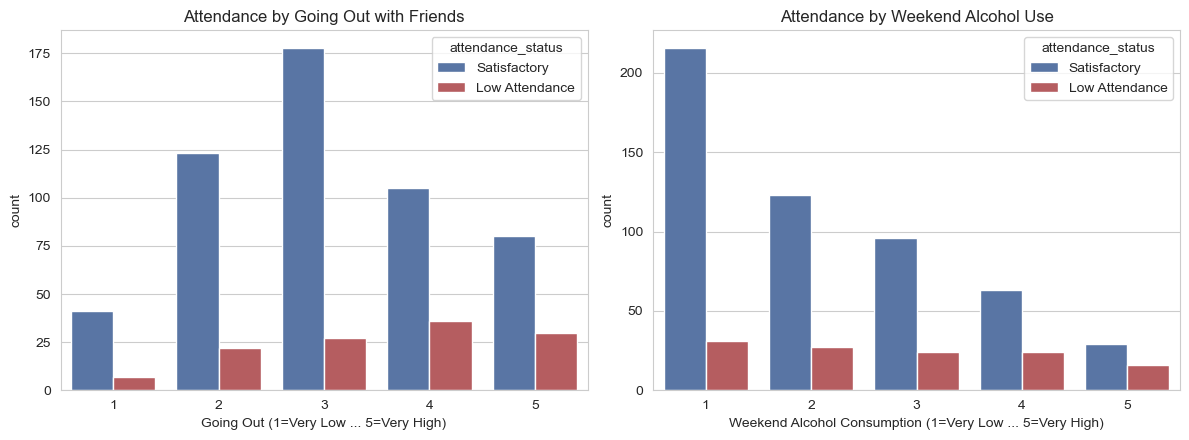

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(data=df, x="goout", hue="attendance_status",
              palette=["#4C72B0", "#C44E52"], ax=axes[0])
axes[0].set_title("Attendance by Going Out with Friends")
axes[0].set_xlabel("Going Out (1=Very Low ... 5=Very High)")

sns.countplot(data=df, x="Walc", hue="attendance_status",
              palette=["#4C72B0", "#C44E52"], ax=axes[1])
axes[1].set_title("Attendance by Weekend Alcohol Use")
axes[1].set_xlabel("Weekend Alcohol Consumption (1=Very Low ... 5=Very High)")

plt.tight_layout()
plt.show()


C:\Users\Hp\AppData\Local\Temp\ipykernel_7020\1828582681.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="attendance_status", y=grade_col,
C:\Users\Hp\AppData\Local\Temp\ipykernel_7020\1828582681.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="attendance_status", y=grade_col,
C:\Users\Hp\AppData\Local\Temp\ipykernel_7020\1828582681.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="attendance_status", y=grade_col,


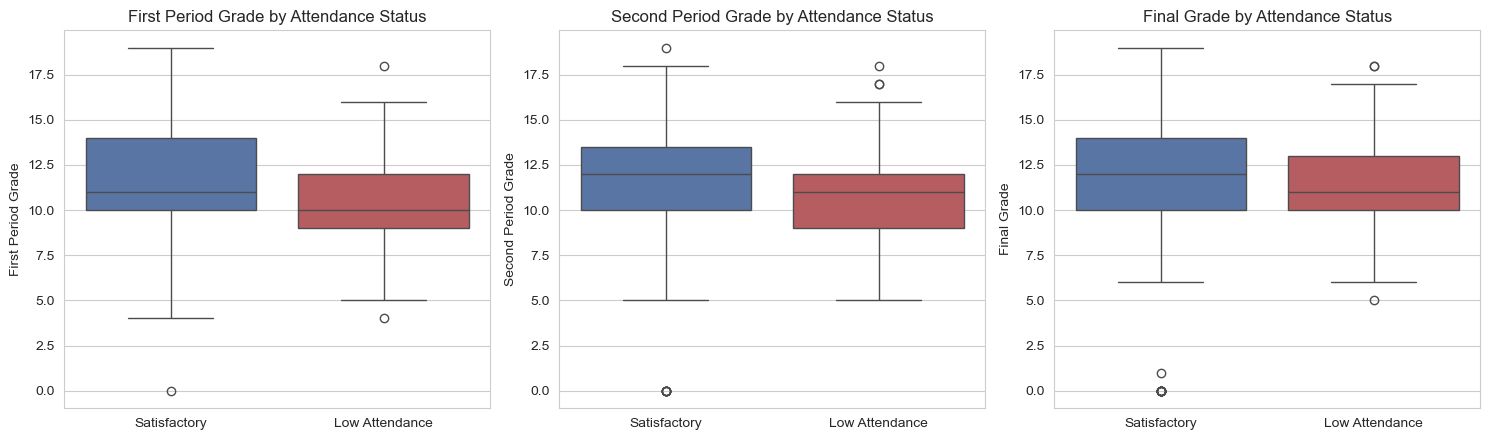

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, grade_col, label in zip(
    axes, ["G1", "G2", "G3"], ["First Period Grade", "Second Period Grade", "Final Grade"]
):
    sns.boxplot(data=df, x="attendance_status", y=grade_col,
                order=["Satisfactory", "Low Attendance"],
                palette=["#4C72B0", "#C44E52"], ax=ax)
    ax.set_title(f"{label} by Attendance Status")
    ax.set_xlabel("")
    ax.set_ylabel(label)

plt.tight_layout()
plt.show()


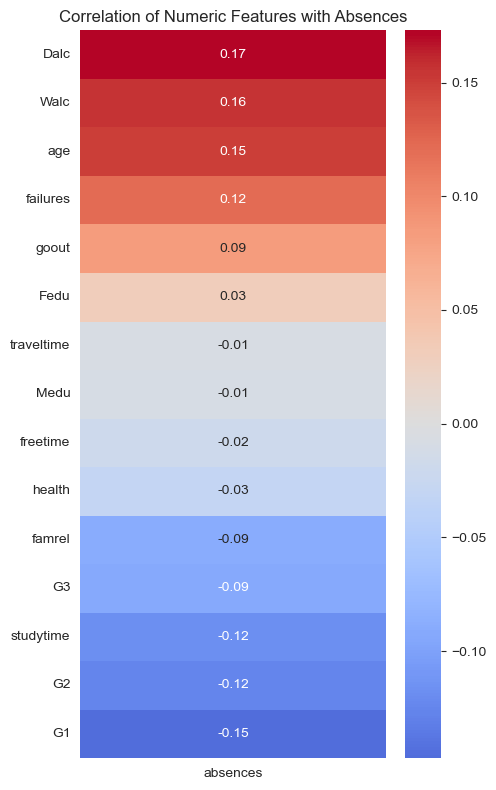

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()[["absences"]].drop("absences").sort_values(
    "absences", ascending=False
)

plt.figure(figsize=(5, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Correlation of Numeric Features with Absences")
plt.tight_layout()
plt.show()


In [12]:
model_df = df.drop(columns=["absences"]).copy()

binary_cols = ["school", "sex", "address", "famsize", "Pstatus", "schoolsup",
               "famsup", "paid", "activities", "nursery", "higher", "internet",
               "romantic"]

le = LabelEncoder()
for col in binary_cols:
    model_df[col] = le.fit_transform(model_df[col])

nominal_cols = ["Mjob", "Fjob", "reason", "guardian"]
model_df = pd.get_dummies(model_df, columns=nominal_cols, drop_first=True)

model_df["target"] = (model_df["attendance_status"] == "Low Attendance").astype(int)
model_df = model_df.drop(columns=["attendance_status"])

print("Final feature matrix shape:", model_df.shape)
model_df.head()


Final feature matrix shape: (649, 42)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,G1,G2,G3,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other,target
0,0,0,18,1,0,0,4,4,2,2,0,1,0,0,0,1,1,0,0,4,3,4,1,1,3,0,11,11,False,False,False,False,False,False,False,True,False,False,False,True,False,0
1,0,0,17,1,0,1,1,1,1,2,0,0,1,0,0,0,1,1,0,5,3,3,1,1,3,9,11,11,False,False,False,False,False,True,False,False,False,False,False,False,False,0
2,0,0,15,1,1,1,1,1,1,2,0,1,0,0,0,1,1,1,0,4,3,2,2,3,3,12,13,12,False,False,False,False,False,True,False,False,False,True,False,True,False,0
3,0,0,15,1,0,1,4,2,1,3,0,0,1,0,1,1,1,1,1,3,2,2,1,1,5,14,14,14,True,False,False,False,False,False,True,False,True,False,False,True,False,0
4,0,0,16,1,0,1,3,3,1,2,0,0,1,0,0,1,1,0,0,4,3,2,1,2,5,11,13,13,False,True,False,False,False,True,False,False,True,False,False,False,False,0


In [13]:
X = model_df.drop(columns=["target"])
y = model_df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:")
print(y_train.value_counts(normalize=True).round(3))


Train shape: (486, 41)  Test shape: (163, 41)
Train class balance:
target
0    0.813
1    0.187
Name: proportion, dtype: float64


In [14]:
dt_model = DecisionTreeClassifier(
    max_depth=4, min_samples_leaf=10, class_weight="balanced",
    random_state=RANDOM_STATE
)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]


In [15]:
svm_model = SVC(
    kernel="rbf", C=1.0, gamma="scale", probability=True,
    class_weight="balanced", random_state=RANDOM_STATE
)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_proba = svm_model.predict_proba(X_test_scaled)[:, 1]


In [16]:
def evaluate(name, y_true, y_pred, y_proba):
    print(f"--- {name} ---")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.3f}")
    print(f"F1-score : {f1_score(y_true, y_pred):.3f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_proba):.3f}")
    print()
    print(classification_report(y_true, y_pred,
                                 target_names=["Satisfactory", "Low Attendance"]))
    print()

evaluate("Decision Tree", y_test, dt_pred, dt_proba)
evaluate("SVM (RBF)", y_test, svm_pred, svm_proba)


--- Decision Tree ---
Accuracy : 0.687
Precision: 0.237
Recall   : 0.290
F1-score : 0.261
ROC-AUC  : 0.531

                precision    recall  f1-score   support

  Satisfactory       0.82      0.78      0.80       132
Low Attendance       0.24      0.29      0.26        31

      accuracy                           0.69       163
     macro avg       0.53      0.54      0.53       163
  weighted avg       0.71      0.69      0.70       163


--- SVM (RBF) ---
Accuracy : 0.761
Precision: 0.357
Recall   : 0.323
F1-score : 0.339
ROC-AUC  : 0.674

                precision    recall  f1-score   support

  Satisfactory       0.84      0.86      0.85       132
Low Attendance       0.36      0.32      0.34        31

      accuracy                           0.76       163
     macro avg       0.60      0.59      0.60       163
  weighted avg       0.75      0.76      0.76       163




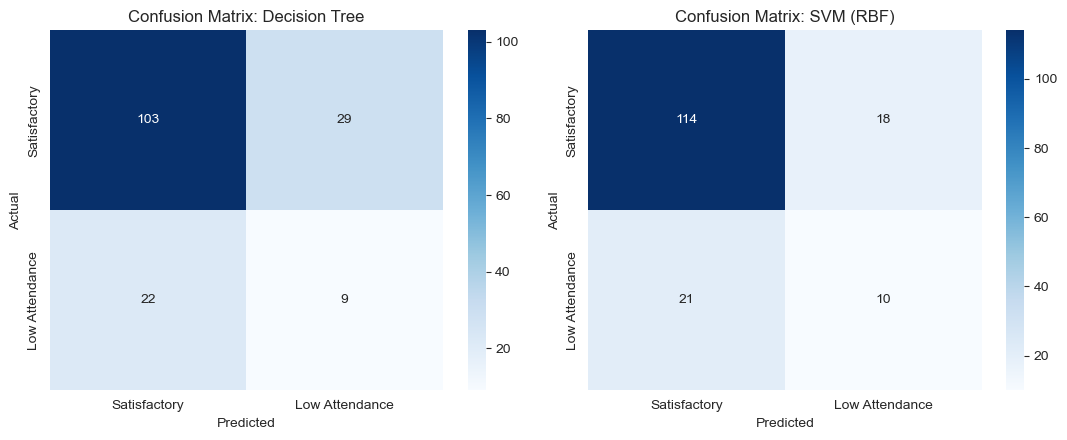

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, name, y_pred in zip(
    axes, ["Decision Tree", "SVM (RBF)"], [dt_pred, svm_pred]
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Satisfactory", "Low Attendance"],
                yticklabels=["Satisfactory", "Low Attendance"], ax=ax)
    ax.set_title(f"Confusion Matrix: {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


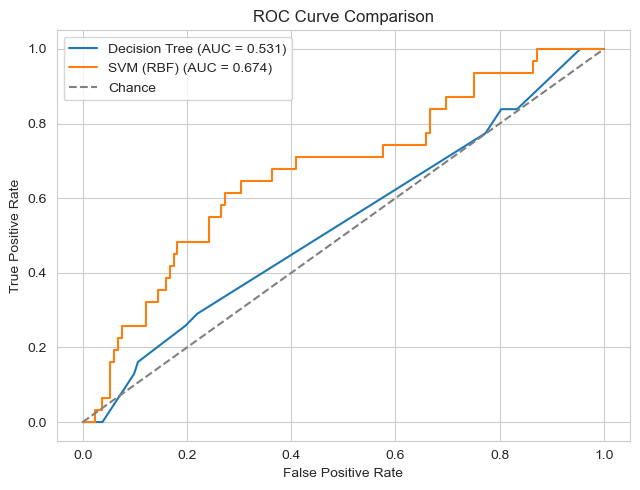

In [18]:
plt.figure(figsize=(6.5, 5))

for y_proba, name in zip(
    [dt_proba, svm_proba], ["Decision Tree", "SVM (RBF)"]
):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()


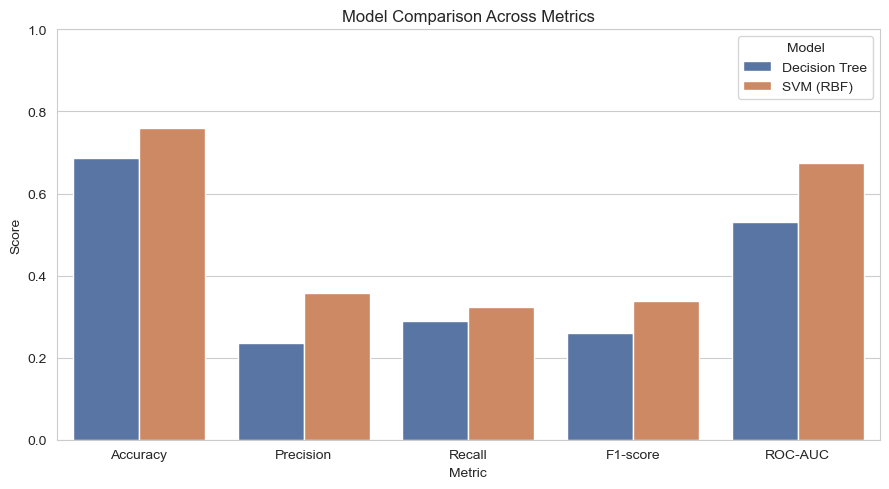

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,SVM (RBF),0.760736,0.357143,0.322581,0.338983,0.674487
0,Decision Tree,0.687117,0.236842,0.290323,0.260870,0.531403


In [19]:
comparison = pd.DataFrame({
    "Model": ["Decision Tree", "SVM (RBF)"],
    "Accuracy": [accuracy_score(y_test, dt_pred), accuracy_score(y_test, svm_pred)],
    "Precision": [precision_score(y_test, dt_pred), precision_score(y_test, svm_pred)],
    "Recall": [recall_score(y_test, dt_pred), recall_score(y_test, svm_pred)],
    "F1-score": [f1_score(y_test, dt_pred), f1_score(y_test, svm_pred)],
    "ROC-AUC": [roc_auc_score(y_test, dt_proba), roc_auc_score(y_test, svm_proba)],
})

comparison_melt = comparison.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(9, 5))
sns.barplot(data=comparison_melt, x="Metric", y="Score", hue="Model",
            palette=["#4C72B0", "#DD8452"])
plt.ylim(0, 1)
plt.title("Model Comparison Across Metrics")
plt.tight_layout()
plt.show()

comparison.sort_values("Accuracy", ascending=False)


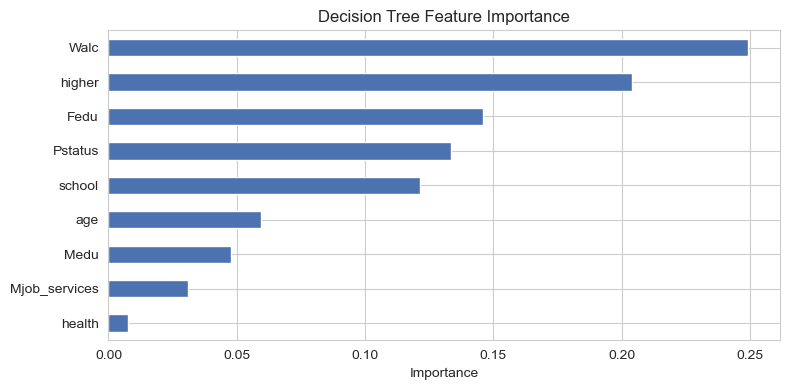

In [20]:
dt_importances = pd.Series(dt_model.feature_importances_, index=X.columns)
dt_importances = dt_importances[dt_importances > 0].sort_values(ascending=True)

plt.figure(figsize=(8, max(4, 0.35 * len(dt_importances))))
dt_importances.plot(kind="barh", color="#4C72B0")
plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


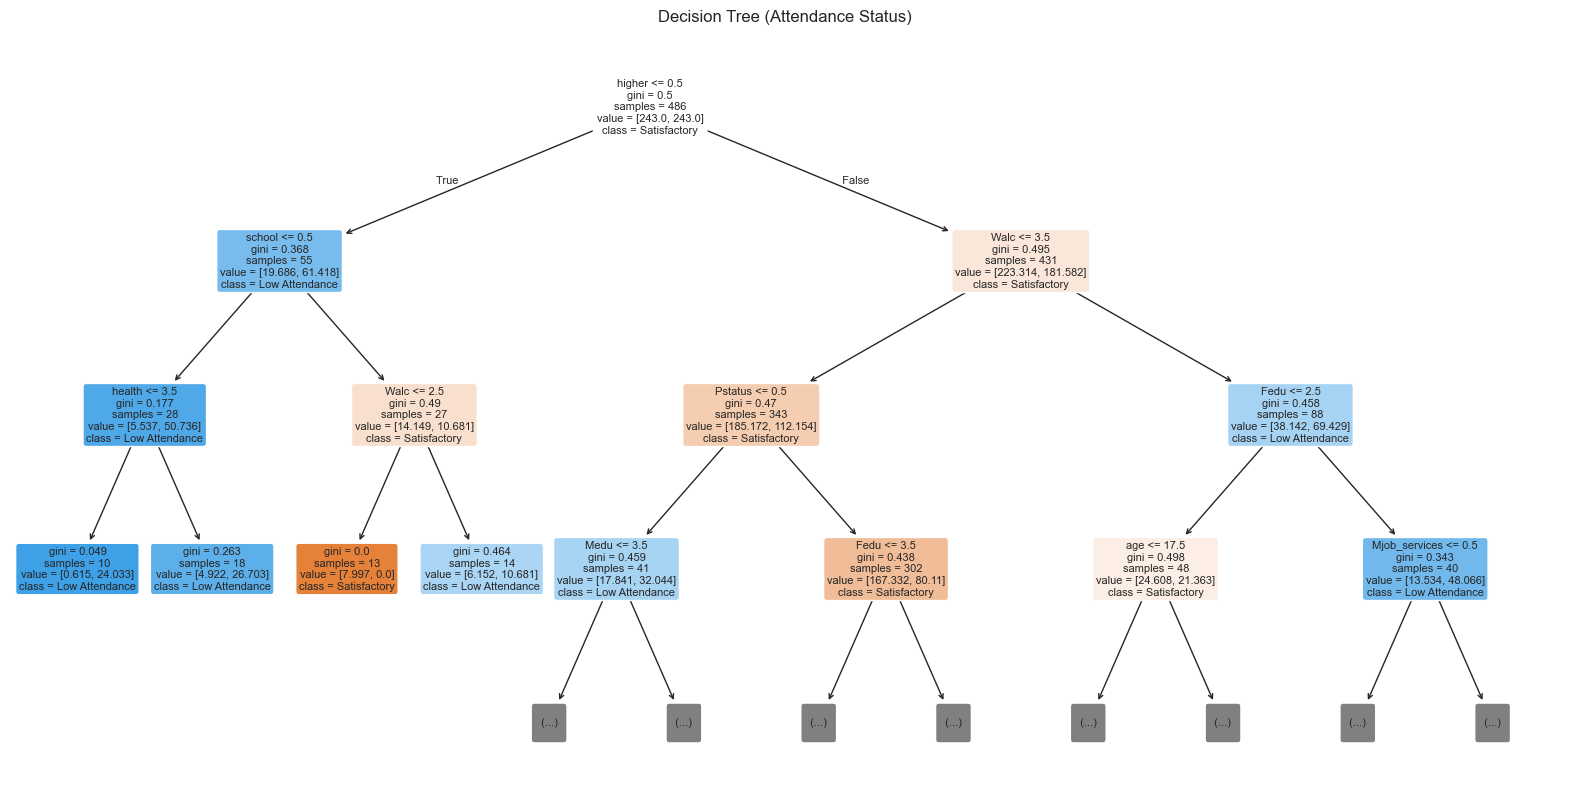

In [21]:
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model, feature_names=X.columns, class_names=["Satisfactory", "Low Attendance"],
    filled=True, rounded=True, fontsize=8, max_depth=3
)
plt.title("Decision Tree (Attendance Status)")
plt.show()
